In [72]:
import numpy as np

np.random.seed(42)
samples = 1000
X = np.random.rand(samples, 2)

epsilon = np.random.rand(samples)

y = 3*X[:, 0] + 5*X[:, 1] + 3 + epsilon

ones = np.ones(samples)
X= np.c_[ones, X]

print(X[:5])

[[1.         0.37454012 0.95071431]
 [1.         0.73199394 0.59865848]
 [1.         0.15601864 0.15599452]
 [1.         0.05808361 0.86617615]
 [1.         0.60111501 0.70807258]]


In [73]:
import matplotlib.pyplot as plt

def gradient_descent(X, y, eta, epochs, step_size):
    m = len(y)
    theta = np.random.rand(3, 1)
    y_local = y.reshape(-1, 1)

    theta_history = []
    epoch_list = []

    for epoch in range(1, epochs + 1):
        gradients = 2/m * X.T @ (X @ theta - y_local)

        theta = theta - eta * gradients

        if epoch  == 1 or epoch % step_size == 1:
            theta_history.append(theta.flatten())
            epoch_list.append(epoch)
    
    return np.array(theta_history), epoch_list

thetas_a, epochs_a = gradient_descent(X, y, eta=0.1, epochs=500, step_size=5)

<>:6: SyntaxWarning: invalid escape sequence '\e'
<>:6: SyntaxWarning: invalid escape sequence '\e'
C:\Users\noorq\AppData\Local\Temp\ipykernel_21776\2624648425.py:6: SyntaxWarning: invalid escape sequence '\e'
  plt.title('Gradient Descent convergence ($\eta = 0.1$)')


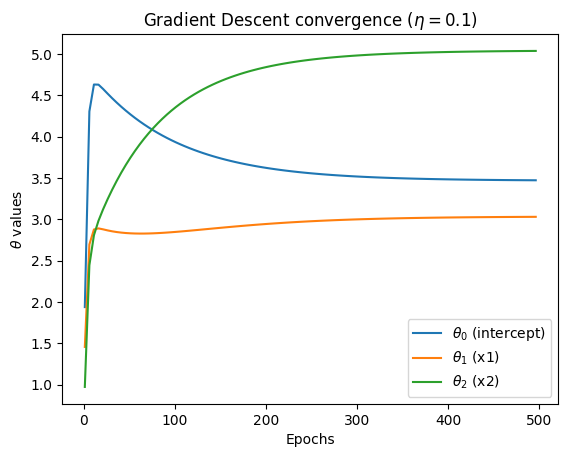

In [74]:
plt.plot(epochs_a, thetas_a[:, 0], label=r'$\theta_0$ (intercept)')
plt.plot(epochs_a, thetas_a[:, 1], label=r'$\theta_1$ (x1)')
plt.plot(epochs_a, thetas_a[:, 2], label=r'$\theta_2$ (x2)')

plt.legend()
plt.title('Gradient Descent convergence ($\eta = 0.1$)')
plt.xlabel('Epochs')
plt.ylabel(r'$\theta$ values')

plt.show()


In [75]:
def stochastic_gradient_descent(X, y, eta, epochs, step):
    m = len(y)
    theta = np.random.randn(3, 1)
    y_vec = y.reshape(-1, 1)

    thetas_history = []
    epoch_points = []

    for epoch in range(epochs):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y_vec[indices]

        for i in range(m):
            xi = X_shuffled[i:i+1]
            yi = y_shuffled[i:i+1]

            gradients = 2 * xi. T @ (xi @ theta - yi)
            theta = theta - eta * gradients
        
        if epoch % step == 0:
            thetas_history.append(theta.flatten())
            epoch_points.append(epoch + 1)
    
    return np.array(thetas_history), epoch_points

thetas_sgd, epochs_sgd = stochastic_gradient_descent(X, y, eta=0.01, epochs=50, step=1)

<>:13: SyntaxWarning: invalid escape sequence '\e'
<>:13: SyntaxWarning: invalid escape sequence '\e'
C:\Users\noorq\AppData\Local\Temp\ipykernel_21776\4033876729.py:13: SyntaxWarning: invalid escape sequence '\e'
  plt.title(f'Stochastic Gradient Dexcent Covergence ($\eta = 0.01$)')


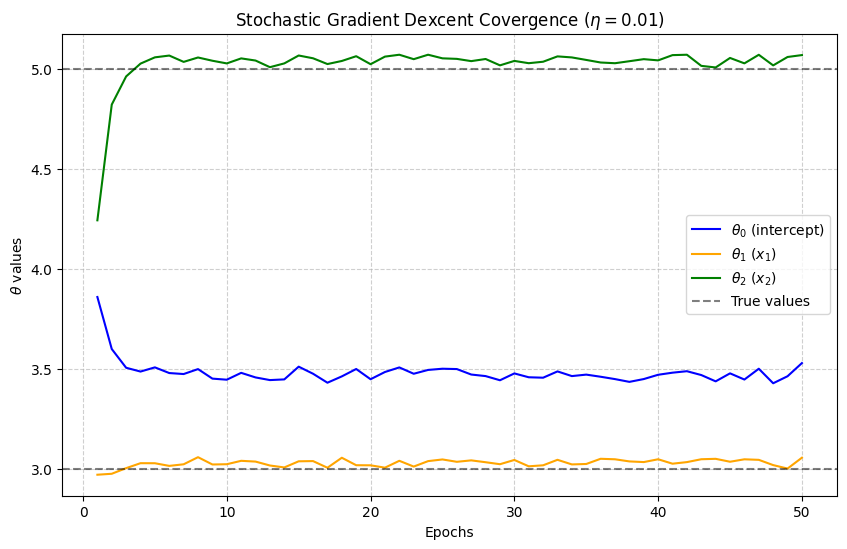

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(epochs_sgd, thetas_sgd[:, 0], label=r'$\theta_0$ (intercept)', color='blue')
plt.plot(epochs_sgd, thetas_sgd[:, 1], label=r'$\theta_1$ ($x_1$)', color='orange')
plt.plot(epochs_sgd, thetas_sgd[:, 2], label=r'$\theta_2$ ($x_2$)', color='green')
plt.axhline(3, color='black', linestyle='--', alpha=0.5, label='True values')

plt.axhline(5, color='black', linestyle='--', alpha=0.5)

plt.legend()
plt.title(f'Stochastic Gradient Dexcent Covergence ($\eta = 0.01$)')
plt.xlabel('Epochs')
plt.ylabel(r'$\theta$ values')
plt.grid(True, linestyle='--', alpha=0.6)


plt.show()

In [77]:
def mini_batch_gradient_descent(X, y, eta, epochs, batch_size):
    m  =len(y)
    theta = np.random.randn(3, 1)
    y_vec = y.reshape(-1, 1)

    thetas_history = []

    for epoch in range(epochs):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y_vec[indices]

        for i in range(0, m, batch_size):
            xi = X_shuffled[i:i+batch_size]
            yi = y_shuffled[i:i+batch_size]

            gradients = 2/len(xi) * xi. T @ (xi @ theta - yi)
            theta = theta - eta * gradients
        
        thetas_history.append(theta.flatten())
    
    return np.array(thetas_history)

thetas_mini = mini_batch_gradient_descent(X, y, eta=0.01, epochs=100, batch_size=32)

<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
C:\Users\noorq\AppData\Local\Temp\ipykernel_21776\4209257366.py:16: SyntaxWarning: invalid escape sequence '\e'
  plt.title(f'Comparison of Convergence ($\eta = {eta}$)')


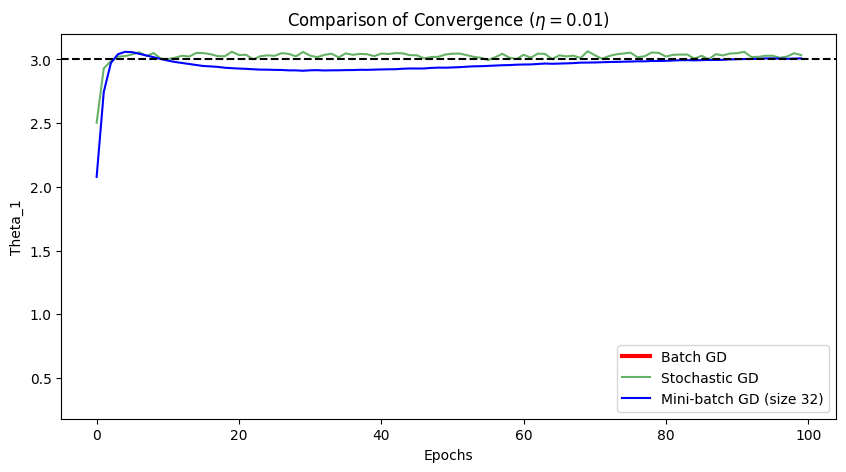

In [78]:
eta = 0.01
epochs = 100

t_batch, _ = gradient_descent(X, y, eta, epochs, step_size=1)
t_sgd, _ = stochastic_gradient_descent(X, y, eta, epochs, step=1)
t_mini = mini_batch_gradient_descent(X, y, eta, epochs, batch_size=32)

plt.figure(figsize=(10, 5))
plt.plot(range(len(t_batch)),t_batch[:,1], label='Batch GD', color='red', linewidth=3)
plt.plot(range(len(t_sgd)),t_sgd[:,1], label='Stochastic GD', color='green', alpha=0.6)
plt.plot(range(len(t_mini)),t_mini[:,1], label='Mini-batch GD (size 32)', color='blue')

plt.axhline(3, color='black', linestyle='--')

plt.legend()
plt.title(f'Comparison of Convergence ($\eta = {eta}$)')
plt.xlabel('Epochs')
plt.ylabel('Theta_1')

plt.show()
